# Confidence-interval plot

Point `INPUTS` at one or more run directories, `.npz` files, or legacy `.npy` files.
Relative paths resolve from the repository root.

A run directory loads **every seed it contains**, discovered from the per-seed files
(`training_rewards_seed<N>.npz`, or `seed<N>/training_rewards.npz` for a seed that was
interrupted). The aggregate `training_rewards.npz` is only a fallback: it covers the
seeds of the most recent invocation, so resuming a run with a different `--seeds` list
overwrites it and silently drops the earlier seeds.

In [1]:
INPUTS = ["runs_new/Swimmer/npg/8x8"]
TITLE = "Swimmer NPG 8x8 across seeds"
XLABEL = "Iteration"
YLABEL = "Average training return"
LABEL = "Mean"
OUTPUT = "runs_new/Swimmer/npg/8x8/training_rewards_ci.png"

# Clip all curves to the shortest when seeds ran a different number of iterations
# (e.g. one was interrupted). False raises instead, so a length mismatch is not silent.
TRUNCATE = False

# Iterations averaged to score each seed in the summary table below.
FINAL_WINDOW = 100

In [2]:
import sys
from pathlib import Path

import numpy as np
from IPython.display import Image, display

working_dir = Path.cwd().resolve()
repo_root = next(
    (
        path
        for path in (working_dir, *working_dir.parents)
        if (path / "vpg" / "analysis.py").is_file()
    ),
    None,
)
if repo_root is None:
    raise FileNotFoundError(
        f"Could not locate the repository root containing vpg/analysis.py "
        f"(searched upwards from {working_dir})"
    )

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from vpg.analysis import load_reward_files, plot_ci
from vpg.stats import student_t_critical_95


def from_repo_root(path):
    path = Path(path).expanduser()
    return path.resolve() if path.is_absolute() else (repo_root / path).resolve()


def describe(data, final_window=100):
    """Print one row per loaded curve, then the mean and its 95% CI.

    Listing each seed makes a missing or outlying seed obvious before the plot is
    read -- a single weak seed widens the interval far more than it moves the mean.
    """
    window = min(final_window, data.curves.shape[1])
    scores = data.curves[:, -window:].mean(axis=1)

    print(f"{len(data.curves)} curves x {data.curves.shape[1]} iterations")
    print(f"\nfinal-{window} mean per curve:")
    order = np.argsort(scores)[::-1]
    for index in order:
        marker = "  <- best" if index == order[0] else ""
        print(f"  {data.labels[index]:>12}  {scores[index]:8.2f}{marker}")

    if len(scores) > 1:
        sd = scores.std(ddof=1)
        half = student_t_critical_95(len(scores)) * sd / np.sqrt(len(scores))
        print(
            f"\nmean {scores.mean():.2f}  sd {sd:.2f}  "
            f"95% CI +/-{half:.2f}  (n={len(scores)})"
        )
    else:
        print("\nsingle curve: no interval (needs >= 2 seeds)")

    print("\nsources:")
    for source in data.sources:
        print(f"  {source.relative_to(repo_root)}")

6 curves x 1200 iterations

final-100 mean per curve:
       seed 23    106.30  <- best
       seed 25    106.03
       seed 28    100.29
       seed 26     99.01
       seed 27     96.46
       seed 24     63.88

mean 95.33  sd 15.90  95% CI +/-16.68  (n=6)

sources:
  runs_new/Swimmer/npg/8x8/training_rewards_seed23.npz
  runs_new/Swimmer/npg/8x8/training_rewards_seed24.npz
  runs_new/Swimmer/npg/8x8/training_rewards_seed25.npz
  runs_new/Swimmer/npg/8x8/training_rewards_seed26.npz
  runs_new/Swimmer/npg/8x8/training_rewards_seed27.npz
  runs_new/Swimmer/npg/8x8/training_rewards_seed28.npz



saved: runs_new/Swimmer/npg/8x8/training_rewards_ci.png


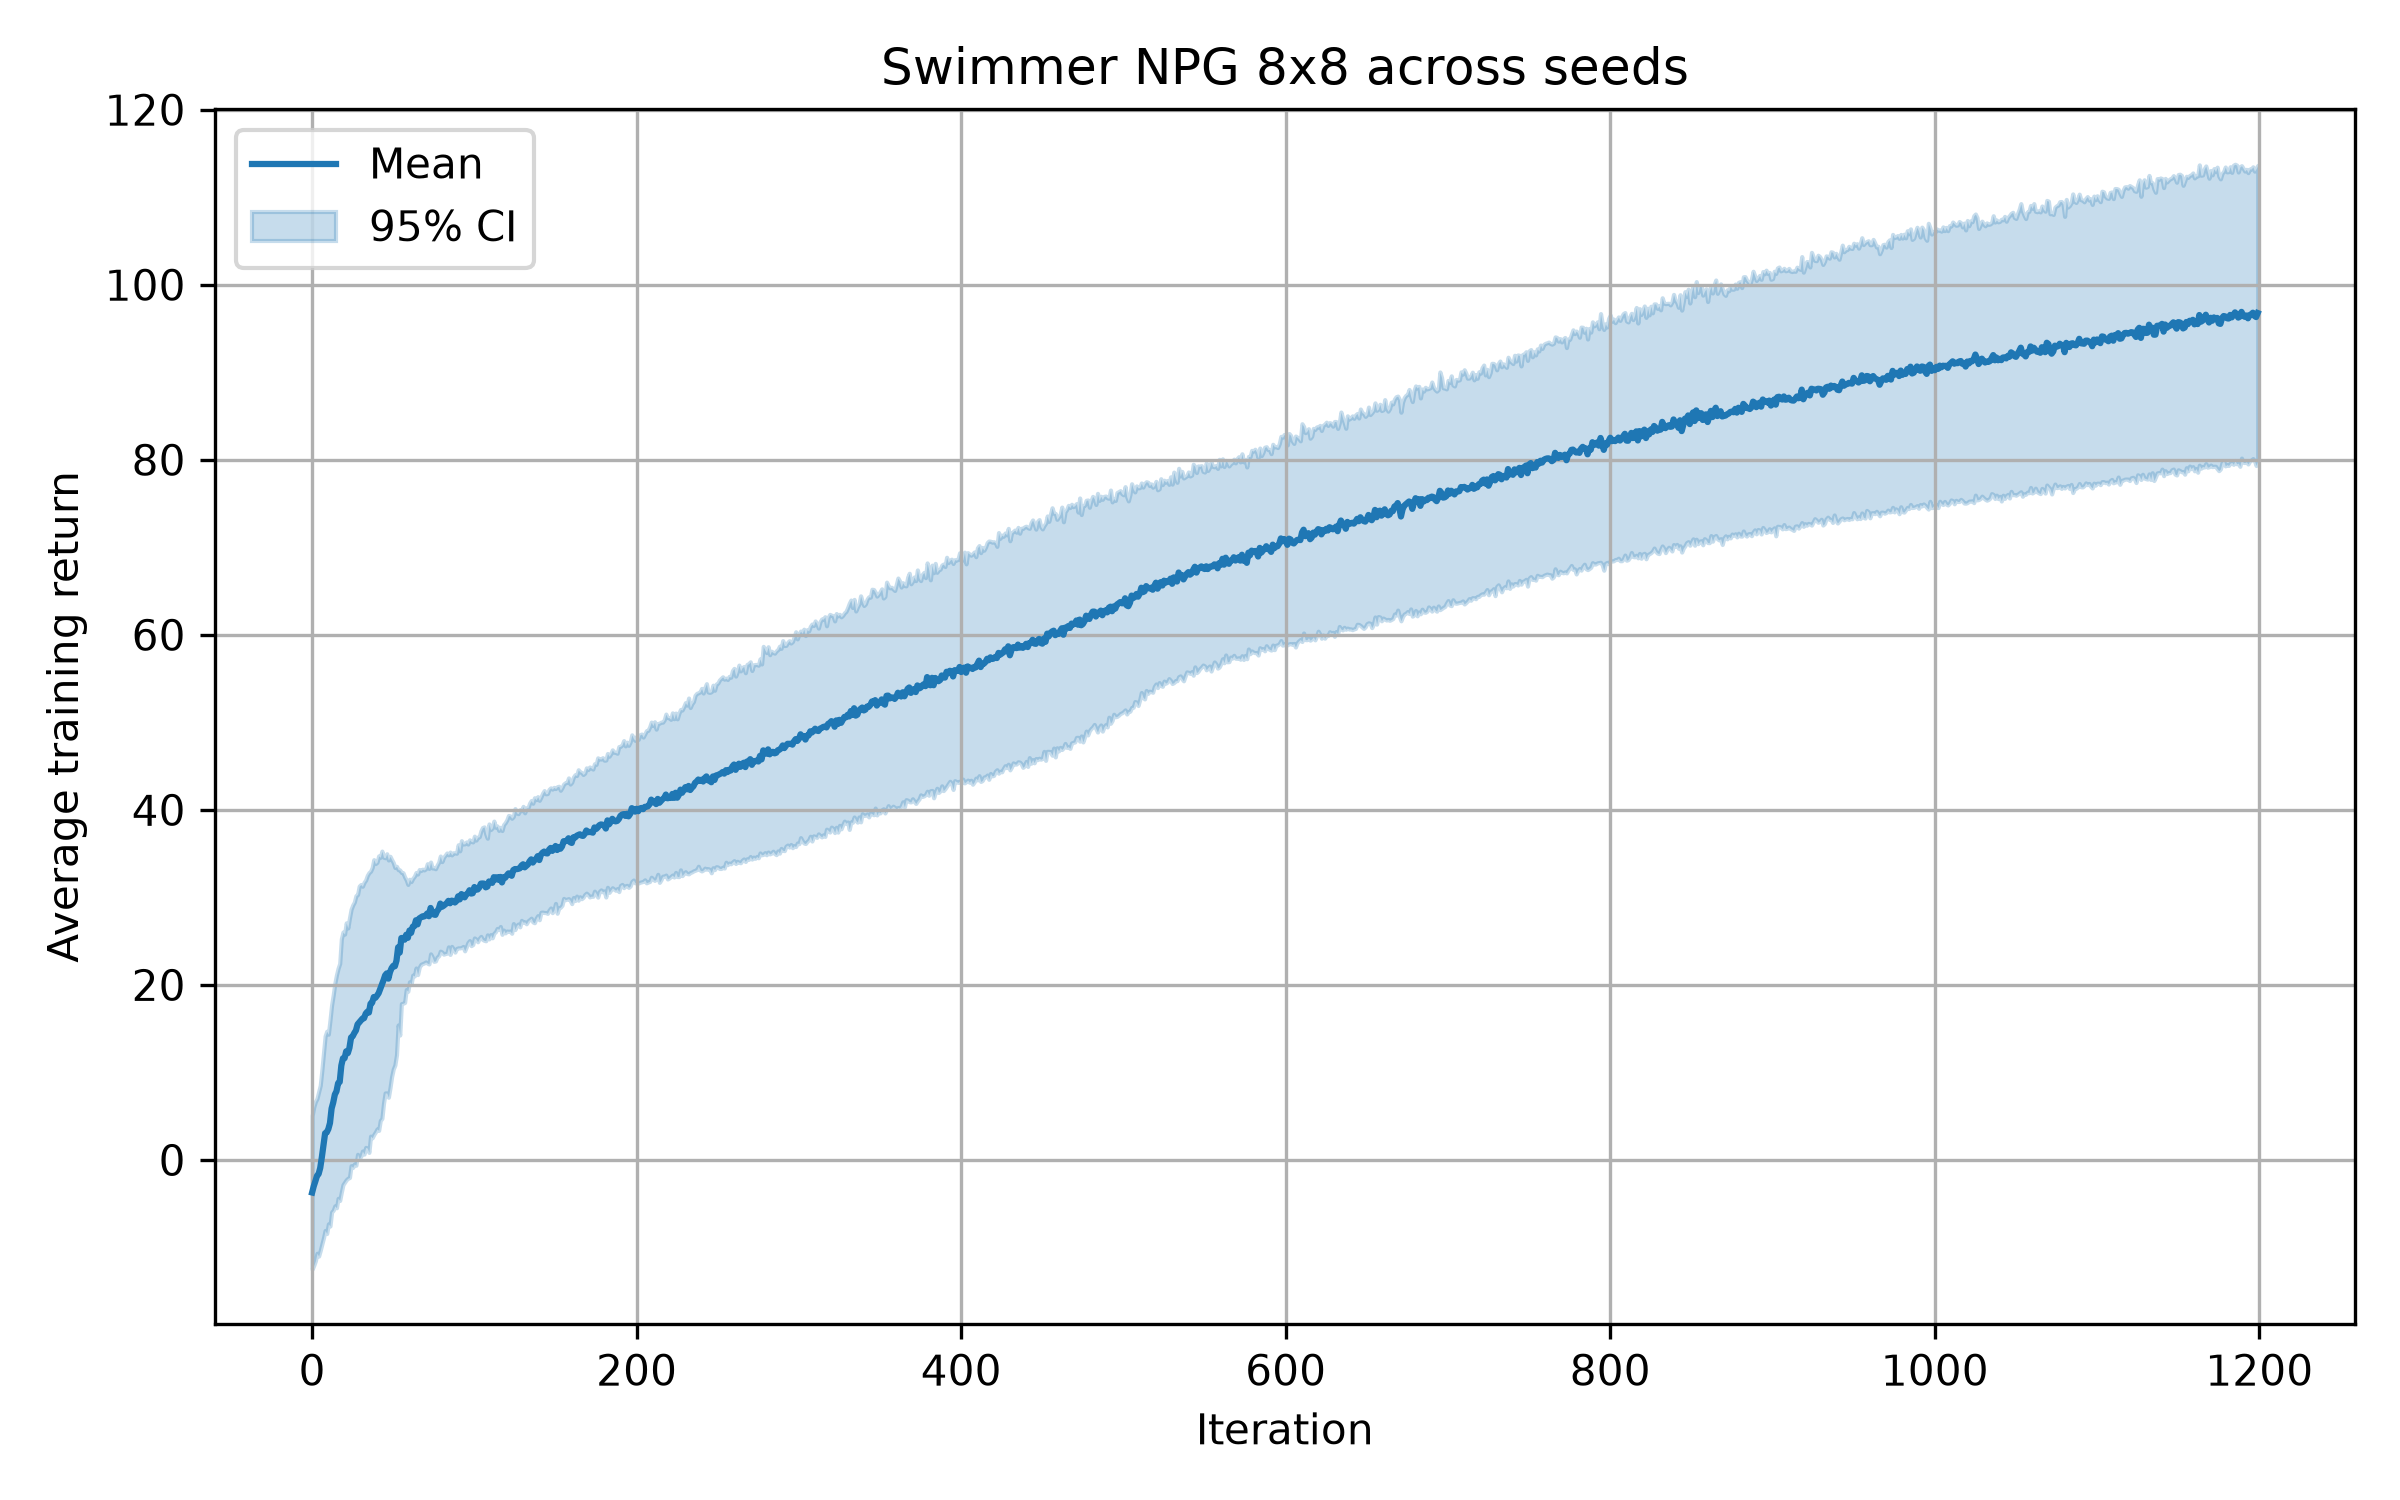

In [3]:
data = load_reward_files(
    [from_repo_root(path) for path in INPUTS], truncate=TRUNCATE
)
describe(data, FINAL_WINDOW)

saved_path = plot_ci(
    data,
    from_repo_root(OUTPUT),
    title=TITLE,
    xlabel=XLABEL,
    ylabel=YLABEL,
    label=LABEL,
)
print(f"\nsaved: {saved_path.relative_to(repo_root)}")
display(Image(filename=str(saved_path)))